# **Breast Cancer Data Analysis**

This data set comes Memorial Sloan Kettering Cancer Center (MSK) and is hosted in cBioPortal. It has breast cancer data collected through 1918 tumor samples from 1756 patients in 2014 untill 2017 with 57 variables including genomic, and pathological information as well as tumor history, grade, cancer type, mutations count ect.. Additionally, the study that includes this data clearly states that all the patients in the dataset gave writen consent to give the tumor sample and have this informations.

“Breast Cancer (MSK, Cancer Cell 2018)” Cbioportal.org, 2018, www.cbioportal.org/study/clinicalData?id=breast_msk_2018. Accessed 7 Apr. 2026.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv('breast_msk_2018_clinical_data.tsv', sep='\t')
df.head()

,Study ID,Patient ID,Sample ID,Cancer Type,Cancer Type Detailed,Disease Free Event,Disease Free (Months),ER PCT Primary,ER Status of Sequenced Sample,ER Status of the Primary,...,Sample Type,Sex,Somatic Status,Stage At Diagnosis,Time To Death (Months),TMB (nonsynonymous),Tumor Sample Histology,Tumor Tissue Origin,T Stage,Patient's Vital Status
0,breast_msk_2018,P-0000004,P-0000004-T01-IM3,Breast Cancer,Breast Invasive Ductal Carcinoma,1,1.1,70,Positive,Positive,...,Primary,Female,Matched,IV,NaN,0.133333,Breast Invasive Ductal Carcinoma,Breast,T1c,Alive
1,breast_msk_2018,P-0000012,P-0000012-T02-IM3,Breast Cancer,Breast Invasive Ductal Carcinoma,0,218.0,0,Negative,Negative,...,Primary,Female,Matched,IIA,NaN,0.033333,Breast Invasive Ductal Carcinoma,Breast,T2,Alive
2,breast_msk_2018,P-0000015,P-0000015-T01-IM3,Breast Cancer,Breast Invasive Ductal Carcinoma,1,68.9,90,Positive,Positive,...,Metastasis,Female,Matched,IB,548.0,0.233333,Breast Invasive Ductal Carcinoma,Breast,T1b,Deceased
3,breast_msk_2018,P-0000041,P-0000041-T01-IM3,Breast Cancer,Breast Invasive Ductal Carcinoma,1,90.2,50,Positive,Positive,...,Metastasis,Female,Matched,IA,637.0,0.333333,Breast Invasive Ductal Carcinoma,Breast,T1b,Deceased
4,breast_msk_2018,P-0000057,P-0000057-T01-IM3,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,1,0.5,80,Positive,Positive,...,Primary,Female,Matched,IV,522.0,0.166667,Breast Mixed Ductal and Lobular Carcinoma,Breast,TX,Deceased


In [25]:
#shape and info
df.shape

(1918, 59)

In [26]:
#shape and info
df.shape

(1918, 59)

### **Project Goal**

**Hypothesizes**
*   Patients with a higher Fraction Genome Altered will have a worse overall survival compared to other patient.
  
*   Patients with higher Mutation count will have a worse overall survival

*   Older patients at diagnoses will have higher fraction genome altered compared to younger patients



## **Data Cleaning and Preprocessing**

In [27]:

#checking for for missing values
df.isnull().sum()

Study ID                                            0
Patient ID                                          0
Sample ID                                           0
Cancer Type                                         0
Cancer Type Detailed                                0
Disease Free Event                                  0
Disease Free (Months)                               0
ER PCT Primary                                    209
ER Status of Sequenced Sample                       0
ER Status of the Primary                            0
Fraction Genome Altered                            22
HER2 FISH Status of Sequenced Sample             1413
HER2 FISH Ratio Value of Sequenced Sample        1524
HER2 FISH Ratio Primary                          1320
HER2 FISH Status (Report and ASCO) of Primary    1184
HER2 IHC Status Primary                             0
HER2 IHC Score of Sequenced Sample                110
HER2 IHC Status of Sequenced Sample                 0
HER2 IHC Score Primary      

In [28]:
#seeing the total amount of missing values
df.isnull().sum().sum()

np.int64(8195)

Since there are only 1918 observation any variable where 50% or more of the values missing. After that I will be filling in the rest of the veriable apropriately.

In [29]:
#droping variable that 50% missing values , I was making alot of mistakes and I asked claued and told be about thresh.
threshold = len(df) * 0.5
df = df.dropna(thresh= threshold, axis = 1)


In [30]:
#filling the remaingning numerical columens with the median so ourliers doesn't affect the data
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [31]:
#filling the remainding Chategorical columns with mode
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [32]:
#cheking for any left over missing values
df.isnull().sum()

Study ID                                   0
Patient ID                                 0
Sample ID                                  0
Cancer Type                                0
Cancer Type Detailed                       0
Disease Free Event                         0
Disease Free (Months)                      0
ER PCT Primary                             0
ER Status of Sequenced Sample              0
ER Status of the Primary                   0
Fraction Genome Altered                    0
HER2 IHC Status Primary                    0
HER2 IHC Score of Sequenced Sample         0
HER2 IHC Status of Sequenced Sample        0
HER2 IHC Score Primary                     0
HER2 Primary Status                        0
Overall HR Status of Sequenced Sample      0
Invasive Carcinoma Diagnosis Age           0
Time to Diagnosis Invasive Carcinoma       0
Last Communication Contact                 0
Primary Tumor Laterality                   0
Menopausal Status At Diagnosis             0
Metastatic

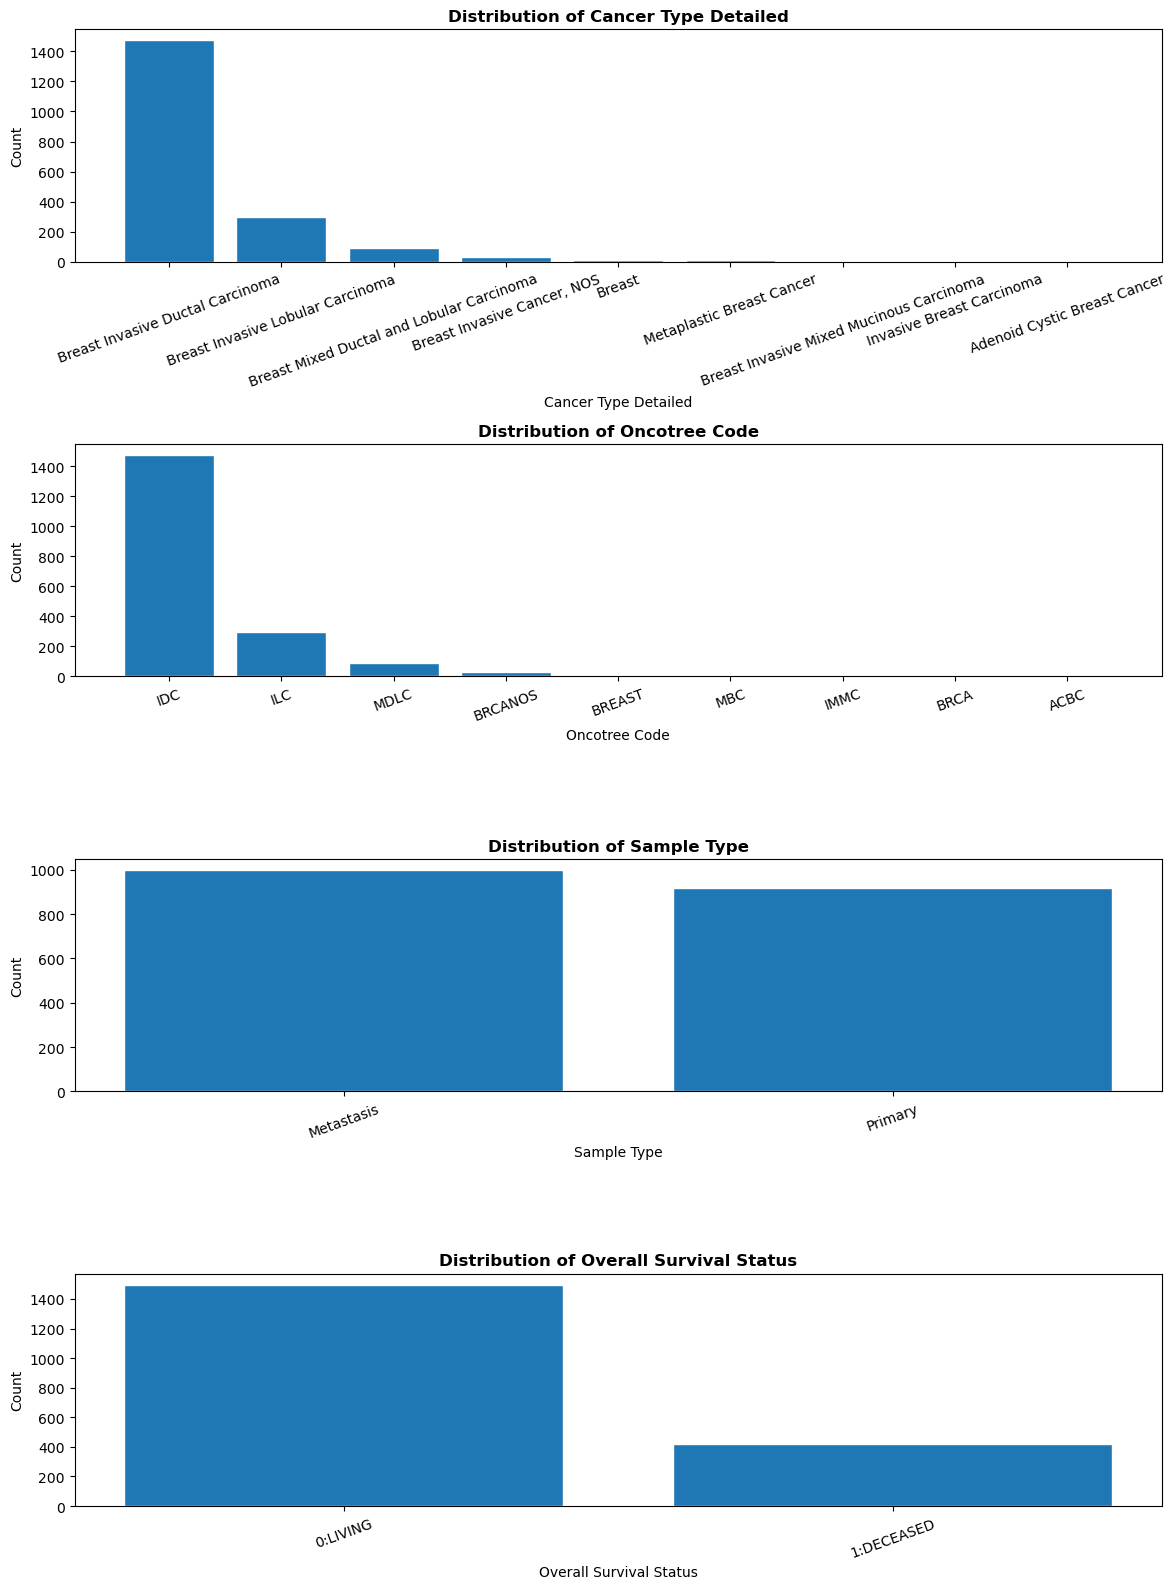

In [33]:
#this is so we know what variable are what.
key_cat = ['Cancer Type Detailed',
           'Oncotree Code',
           'Sample Type',
           'Overall Survival Status']

plt.figure(figsize=(12, len(key_cat) * 4))

for i, col in enumerate(key_cat, 1):
    plt.subplot(len(key_cat), 1, i)

    counts = df[col].value_counts()
    plt.bar(counts.index.astype(str), counts.values, edgecolor='white')
    plt.title(f'Distribution of {col}', fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Count')

    plt.xticks(rotation = 20)

plt.tight_layout()
plt.show()


In [34]:
#Label encodeing to change all the cat variables into numericals
for col in cat_cols:
    df[col], _ = pd.factorize(df[col])

In [35]:
#this was just to check that my factorization worked and it did
df['Overall Survival Status'].unique()

array([0, 1])

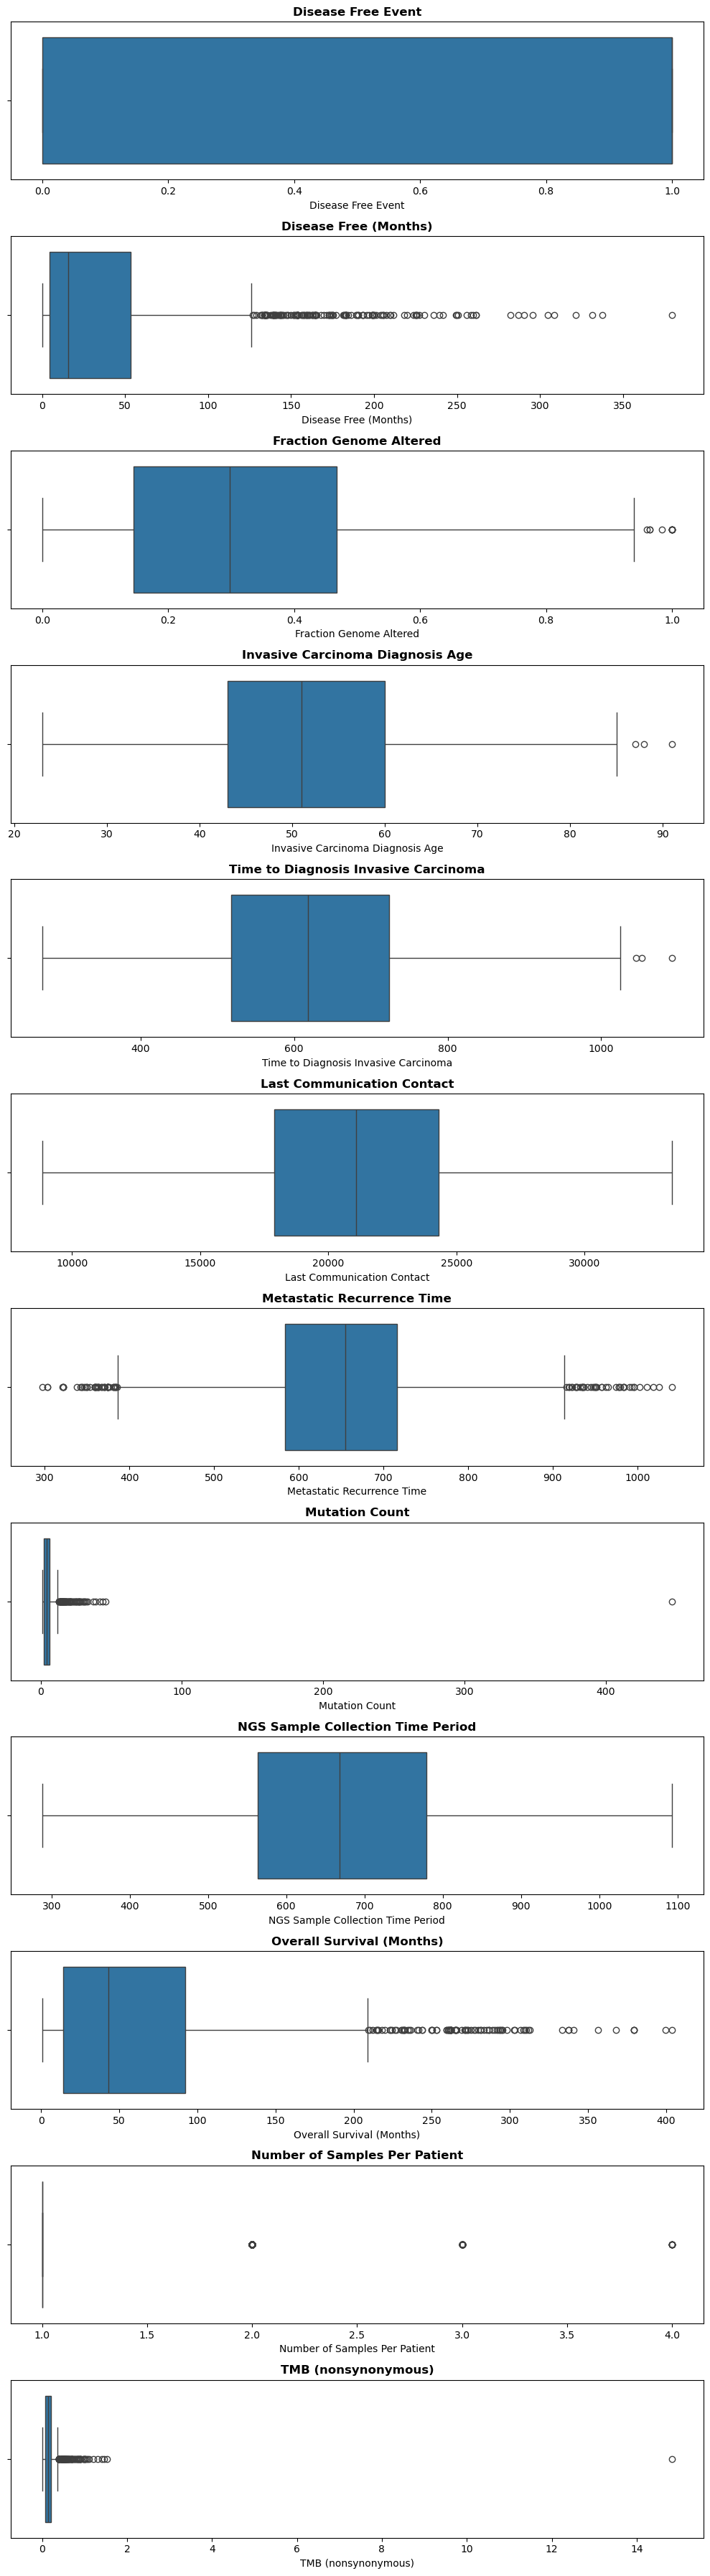

In [36]:
#Visualising the outliers with boxplots
#only finding outliers for the numerical ones we found earliers
plt.figure(figsize=(10, len(num_cols) * 3))


# so I got this form claude when I was trying to see the oulier of all the variables since I wasn't sure which ones my partner wanted to do
# for the visualyzation part and its better to have all insetead of not enough.
# also I just did the num variables since they are the ones with significant outliers.
for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 1, i)
    sns.boxplot(x=df[col])
    plt.title(col, fontweight = 'bold')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

Some of theses graphs have many outliers and I want to keep those since that can be interesting to analyse so I will be using the z-score method since I believe it is important to keep the original scale of the variables.

In [37]:
num_cols

['Disease Free Event',
 'Disease Free (Months)',
 'Fraction Genome Altered',
 'Invasive Carcinoma Diagnosis Age',
 'Time to Diagnosis Invasive Carcinoma',
 'Last Communication Contact',
 'Metastatic Recurrence Time',
 'Mutation Count',
 'NGS Sample Collection Time Period',
 'Overall Survival (Months)',
 'Number of Samples Per Patient',
 'TMB (nonsynonymous)']

### **Removing Outliers** 

In [38]:
#I realized that it is best to have all the num cols go through the removing of outlier process
voutliers = num_cols

In [39]:
#calculating the z- score
z_scores = (df[voutliers] - df[voutliers].mean()) / df[voutliers].std()
z_scores
# I did use mode and median to fill in the missing variable so that is bias toward com 

,Disease Free Event,Disease Free (Months),Fraction Genome Altered,Invasive Carcinoma Diagnosis Age,Time to Diagnosis Invasive Carcinoma,Last Communication Contact,Metastatic Recurrence Time,Mutation Count,NGS Sample Collection Time Period,Overall Survival (Months),Number of Samples Per Patient,TMB (nonsynonymous)
0,0.603294,-0.710095,-0.098382,-1.239931,-1.239267,-1.474479,-1.669555,-0.090604,-1.510518,-0.498325,-0.402152,-0.075086
1,-1.656702,3.343684,1.705889,-0.742818,-0.745171,0.304265,0.029992,-0.362414,-1.018703,2.195890,-0.402152,-0.346812
2,0.603294,0.557062,-0.098382,-1.239931,-1.205251,-0.982448,-1.075933,0.181207,-0.902580,0.462347,-0.402152,0.196640
3,0.603294,0.955151,1.464552,-0.742818,-0.764491,-0.368994,-0.384730,0.453018,-0.328795,0.824946,-0.402152,0.468366
4,0.603294,-0.721308,0.877790,-1.157079,-1.146189,-1.160277,-1.563841,0.000000,-1.209964,-0.034602,-0.402152,0.015489
...,...,...,...,...,...,...,...,...,...,...,...,...
1913,-1.656702,-0.676453,-1.467877,0.582816,0.601398,0.165400,0.029992,-0.090604,0.313296,-0.911486,-0.402152,-0.075086
1914,-1.656702,-0.717570,-1.373000,-0.328558,-0.316899,-0.766334,0.029992,-0.362414,-0.595195,-0.943268,-0.402152,-0.346812
1915,-1.656702,-0.700750,-1.079619,1.328485,1.360171,0.913868,0.029992,-0.271811,1.064680,-0.930266,-0.402152,-0.256236
1916,-1.656702,-0.650288,-1.361947,0.997077,0.968469,0.540994,0.029992,-0.181207,0.688988,-0.891261,-0.402152,-0.165661


In [40]:
# the new shape of the dataset after cleaning
outliers = df[abs(z_scores) > 3]
df_truncated_zscore = df[(abs(z_scores) < 3).all(axis=1)]
df_truncated_zscore.shape

(1796, 54)

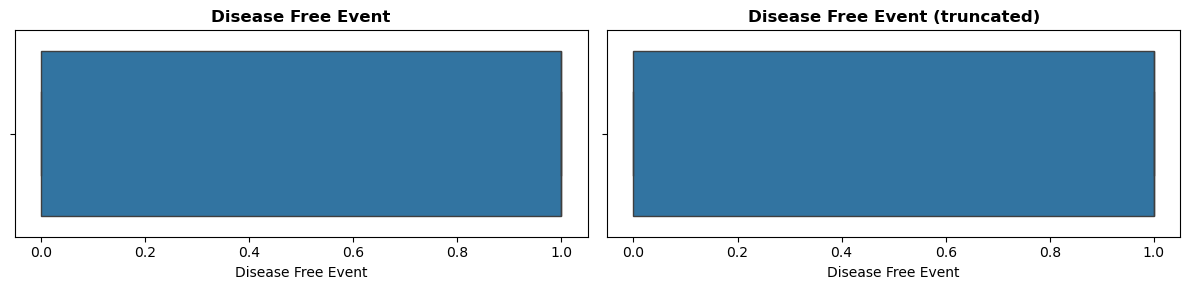

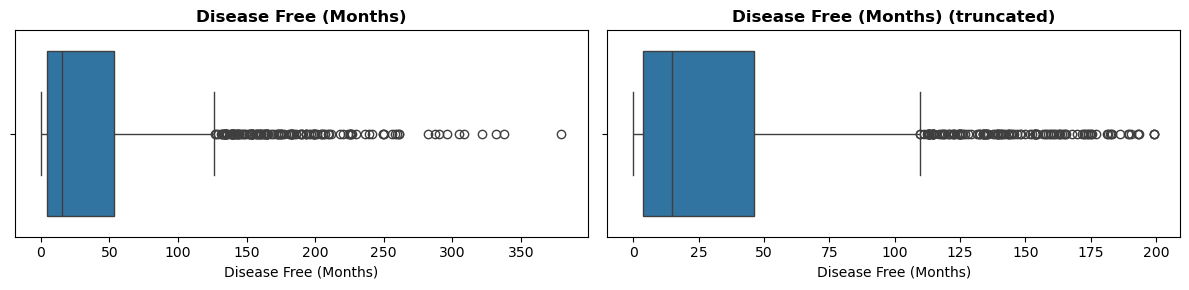

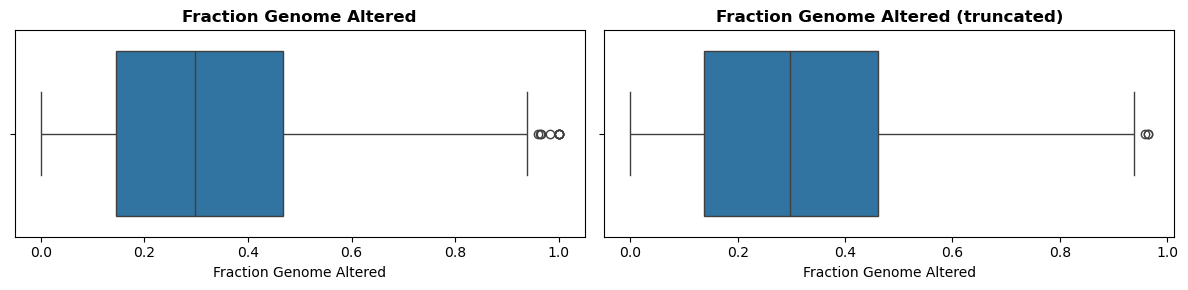

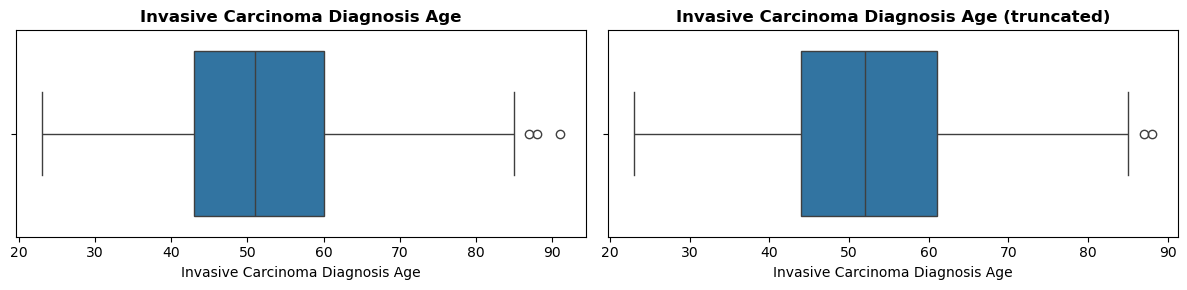

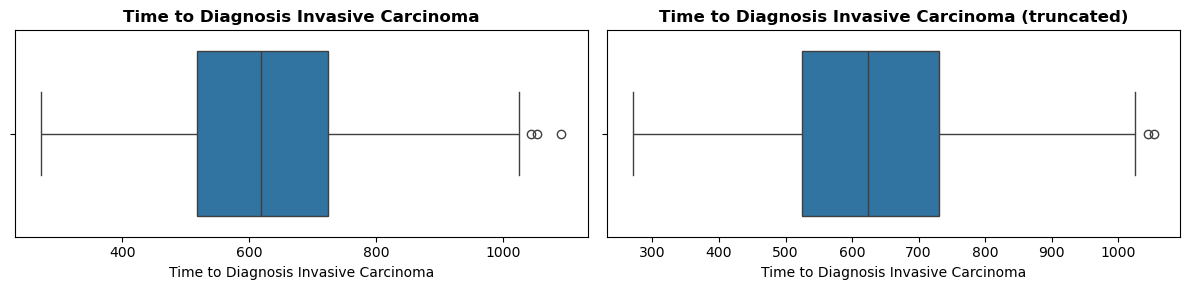

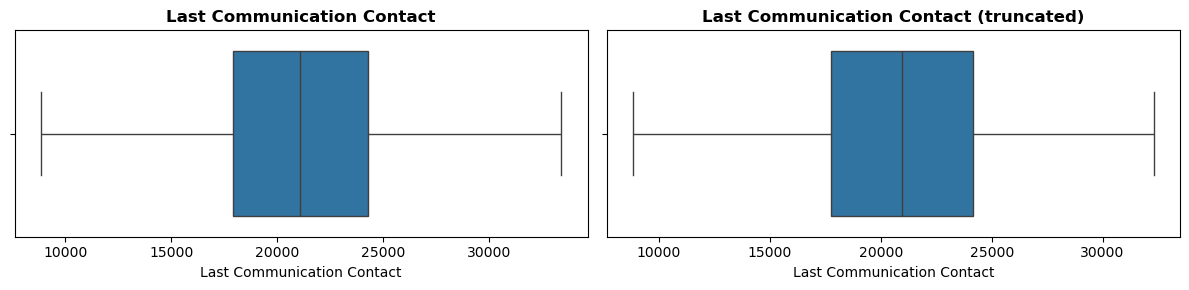

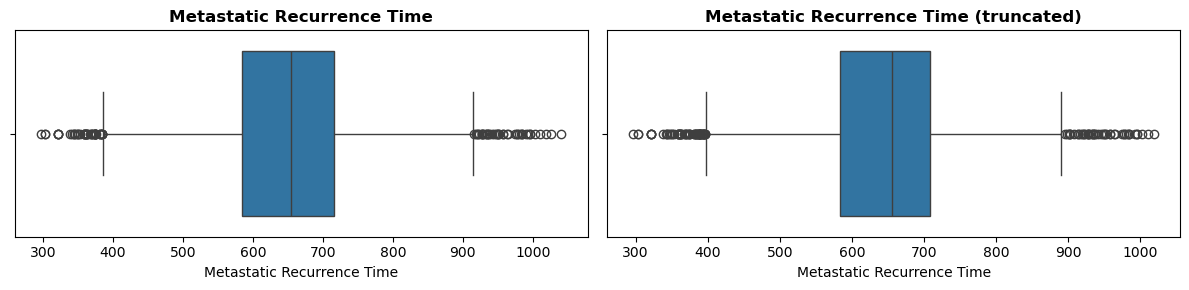

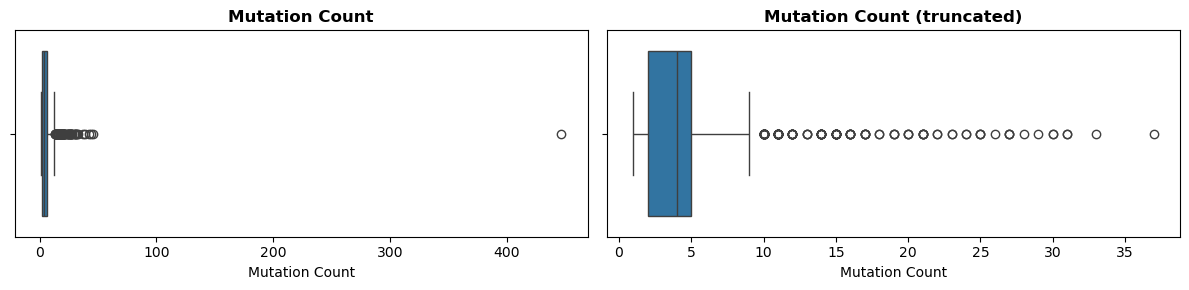

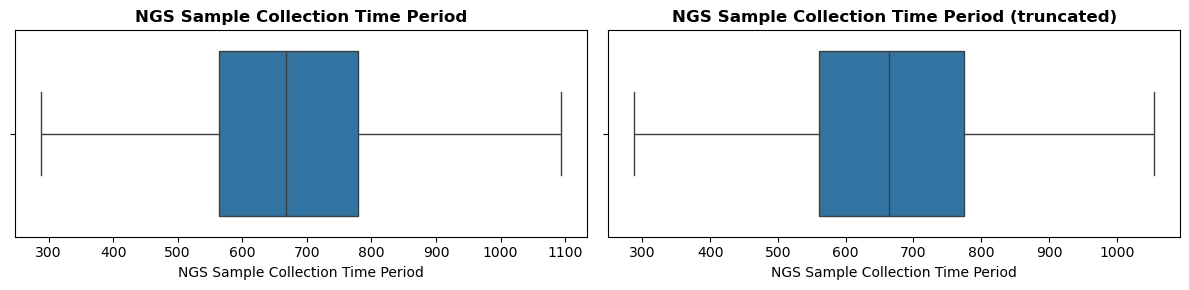

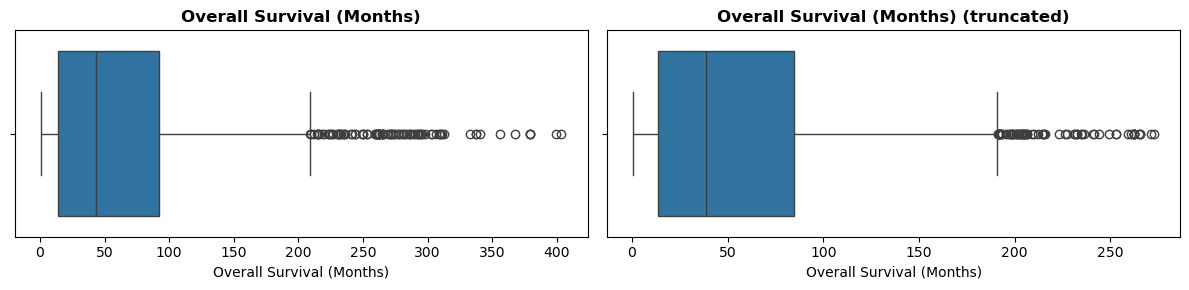

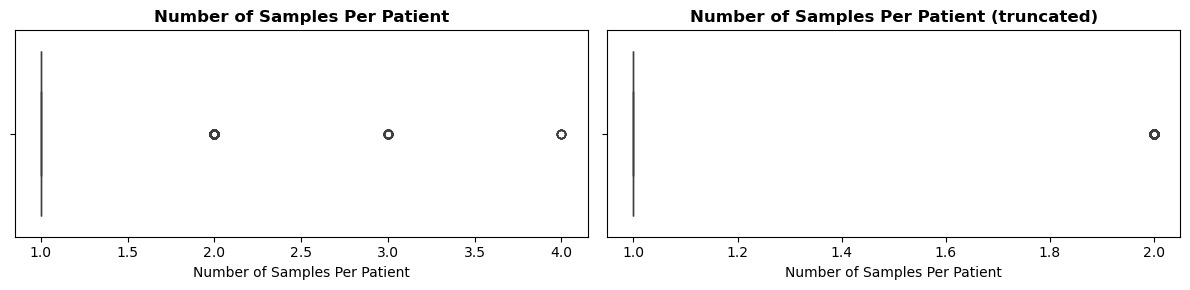

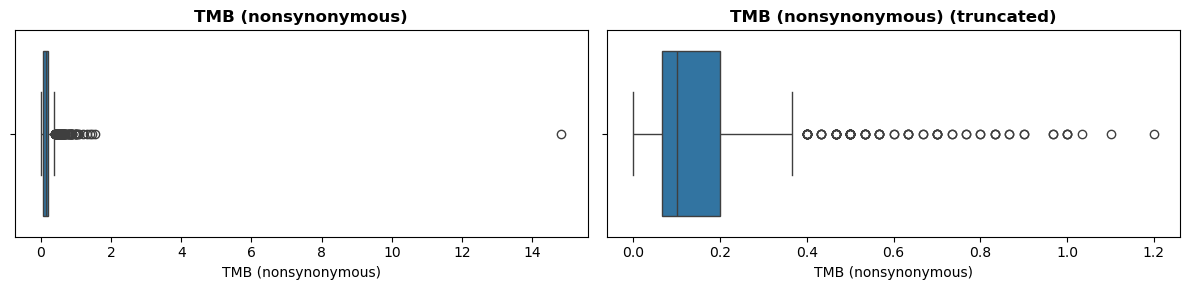

In [41]:
for column in voutliers:
    plt.figure(figsize=(12, 3))
    
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df[column])
    plt.title(column,  fontweight = 'bold')
    plt.xlabel(column)

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_truncated_zscore[column])
    plt.title(column + ' (truncated)', fontweight = 'bold')
    plt.xlabel(column)
    
    plt.tight_layout()
    plt.show()

### **Findings**
There is a clear difference in the graphs. Z- score keeps the main significan outliers withough messing up the scale since this is medical data and would be harder to understand with a different scale.

## **Exploritory Data Analysis**

In [42]:
#for my sanity I will made df_truncated_zscore into dfb for dataFrame breats cancer
dfb = df_truncated_zscore
print('Current status of our dataset after cleaning')
print("Dataset shape: ",dfb.shape)
print('\n \tBasic data info')

dfb.describe()

Current status of our dataset after cleaning
Dataset shape:  (1796, 54)

 	Basic data info


,Study ID,Patient ID,Sample ID,Cancer Type,Cancer Type Detailed,Disease Free Event,Disease Free (Months),ER PCT Primary,ER Status of Sequenced Sample,ER Status of the Primary,...,Site of Sample,Sample Type,Sex,Somatic Status,Stage At Diagnosis,TMB (nonsynonymous),Tumor Sample Histology,Tumor Tissue Origin,T Stage,Patient's Vital Status
count,1796.0,1796.000000,1796.000000,1796.000000,1796.000000,1796.000000,1796.000000,1796.000000,1796.000000,1796.000000,...,1796.000000,1796.000000,1796.000000,1796.0,1796.000000,1796.000000,1796.000000,1796.0,1796.000000,1796.000000
mean,0.0,870.669265,975.538976,0.004454,0.477728,0.718820,32.925668,8.227728,0.242762,0.167038,...,3.682071,0.501114,0.006125,0.0,2.693207,0.147383,0.500557,0.0,2.133630,0.223831
std,0.0,510.365928,557.040061,0.066611,1.004200,0.449701,42.169110,10.119064,0.495189,0.406006,...,5.071932,0.500138,0.078042,0.0,2.101857,0.136208,1.102289,0.0,2.637836,0.416926
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
25%,0.0,424.750000,488.750000,0.000000,0.000000,0.000000,3.600000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,1.000000,0.066667,0.000000,0.0,0.000000,0.000000
50%,0.0,867.500000,984.500000,0.000000,0.000000,1.000000,14.750000,5.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,0.0,3.000000,0.100000,0.000000,0.0,1.000000,0.000000
75%,0.0,1312.250000,1462.250000,0.000000,0.000000,1.000000,46.025000,7.000000,0.000000,0.000000,...,7.000000,1.000000,0.000000,0.0,4.000000,0.200000,0.000000,0.0,3.000000,0.000000
max,0.0,1755.000000,1917.000000,1.000000,8.000000,1.000000,199.200000,63.000000,2.000000,2.000000,...,30.000000,1.000000,1.000000,0.0,8.000000,1.200000,10.000000,0.0,16.000000,1.000000


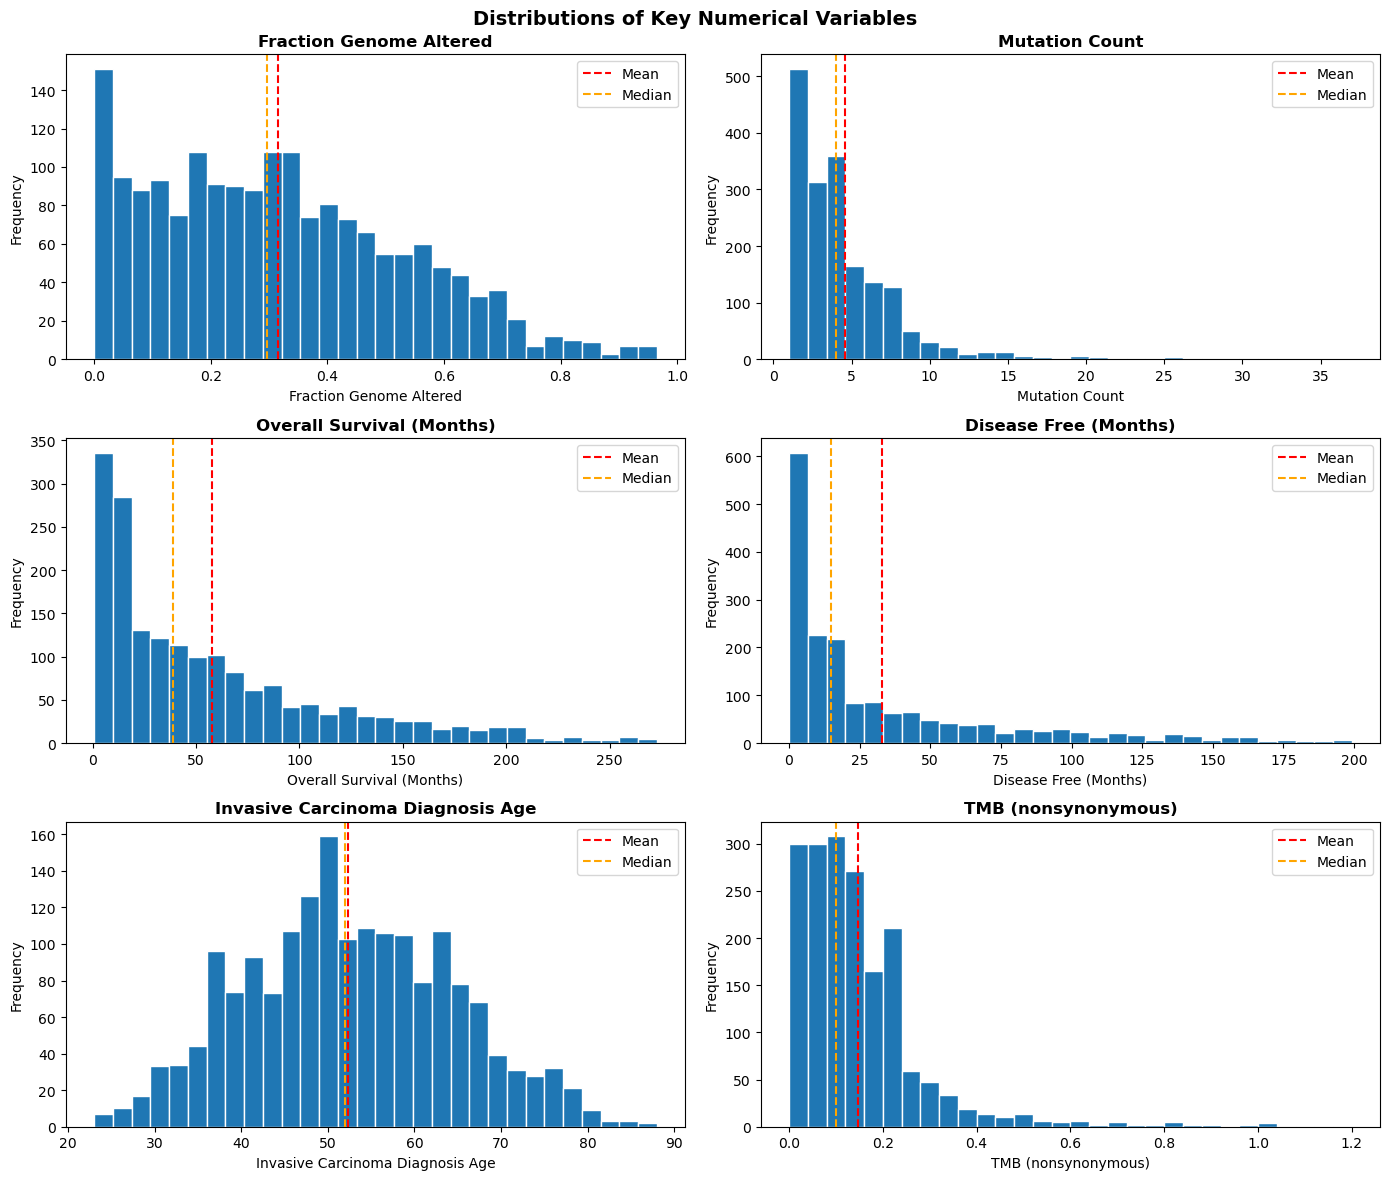

In [43]:
# distribution of key variables I picked the onese that are both interesting and related to hypothesis
key_num = [
    'Fraction Genome Altered',
    'Mutation Count',
    'Overall Survival (Months)',
    'Disease Free (Months)',
    'Invasive Carcinoma Diagnosis Age',
    'TMB (nonsynonymous)'
]

#the plot yay
plt.figure(figsize=(14, 12))

for i, col in enumerate(key_num, 1):
    plt.subplot(3, 2, i)
    plt.hist(df_truncated_zscore[col], bins=30, edgecolor = 'white')

    plt.axvline(df_truncated_zscore[col].mean(), color='red', linestyle='--', label='Mean')
    plt.axvline(df_truncated_zscore[col].median(), color='orange', linestyle='--', label='Median')

    plt.title(col, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend()

plt.suptitle('Distributions of Key Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### **The Findings**

*  Fraction Genome Altered (FGA) - Right skewed, So most patients have more gene stability which is good for the patient.

*   Mutation Count/ TMB - Both are very rightskewed, consistent with The FGA where the tumors have few mutations but some are hypermutated.

*   Overall survival and Disease Free (months) - Very right skewed agains which indicates that most patients didn't survive that long. And that there was short follow up.

*   Age at diagnosis - Is a bell curve, centered at around 50's.


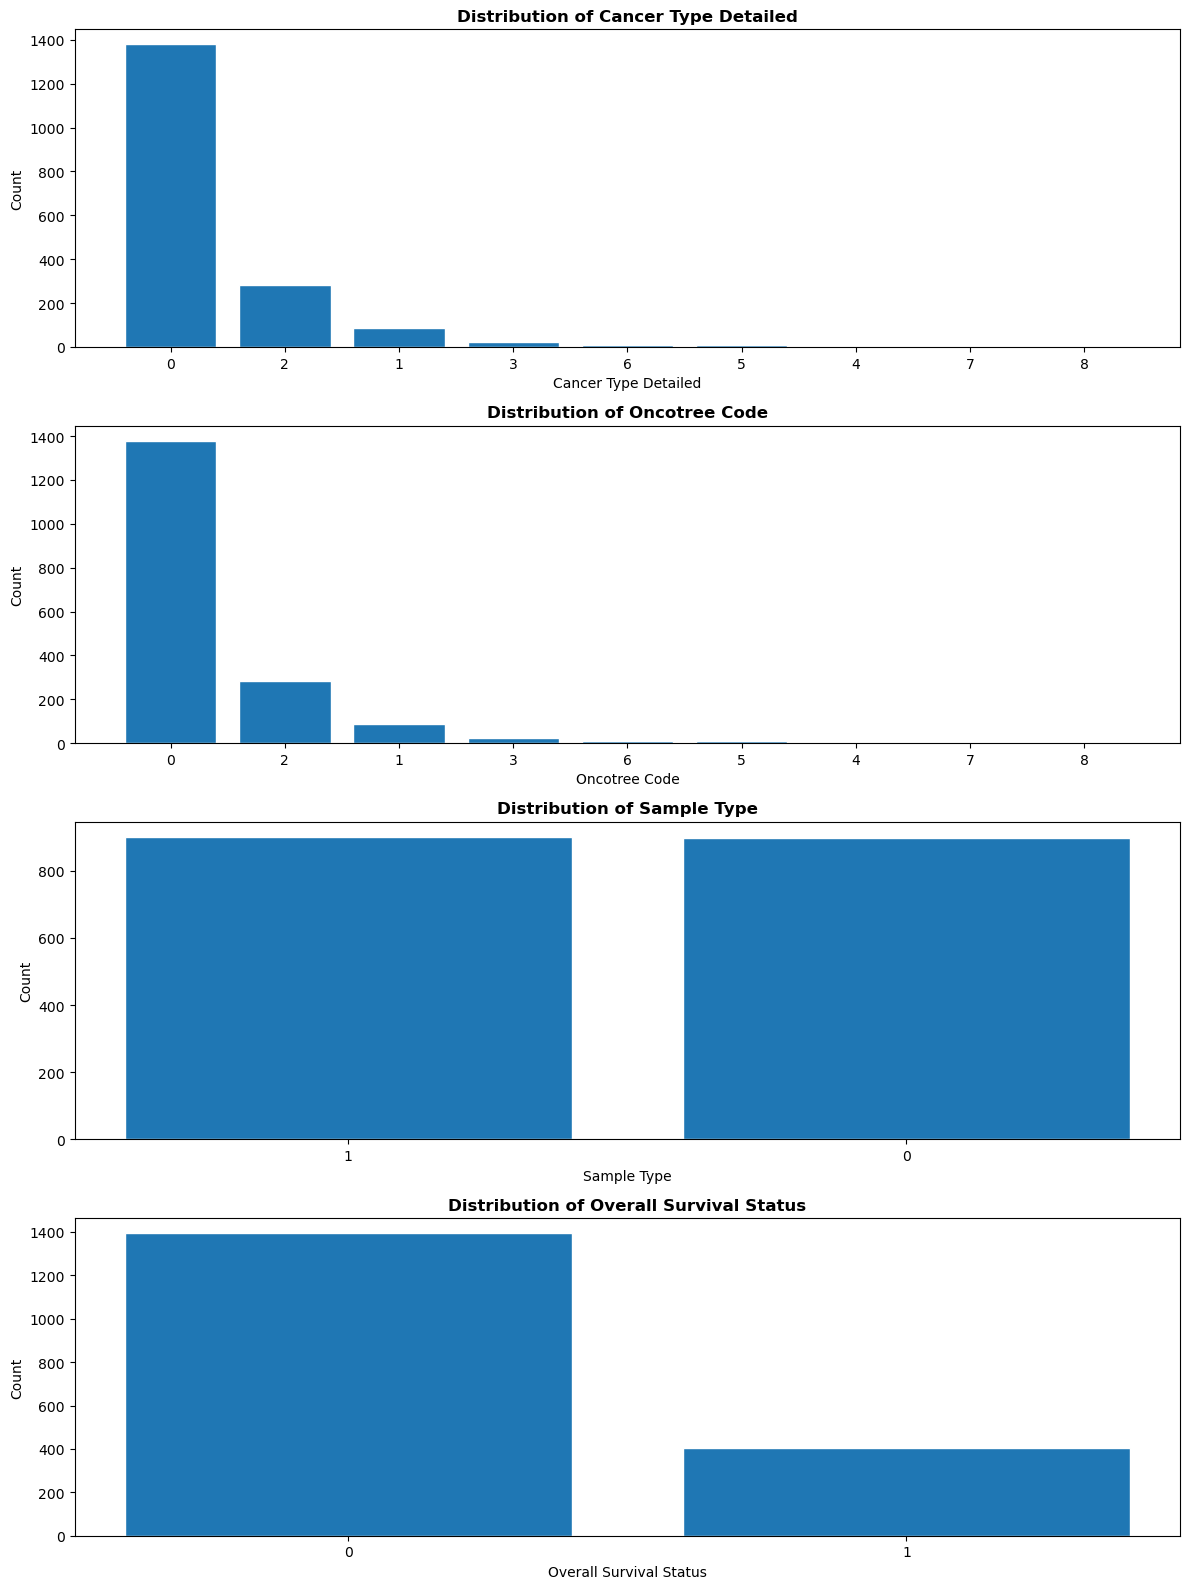

In [44]:
#doing the same for the cat variables
key_cat = ['Cancer Type Detailed',
           'Oncotree Code',
           'Sample Type',
           'Overall Survival Status']

plt.figure(figsize=(12, len(key_cat) * 4))

for i, col in enumerate(key_cat, 1):
    plt.subplot(len(key_cat), 1, i)

    counts = dfb[col].value_counts()
    plt.bar(counts.index.astype(str), counts.values, edgecolor='white')
    plt.title(f'Distribution of {col}', fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()


### **Findings**

*   Cancer Type / Oncotree Code -  The dataset is dominated by a few major subtypes (IDC — Invasive Ductal Carcinoma), which is expected for breast cancer.
*   Sample Type - Most samples are primary tumors, there are fewer metastatic samples, which is important context for survival analysis.
*   Overall Status - I belive that 0 is the dead



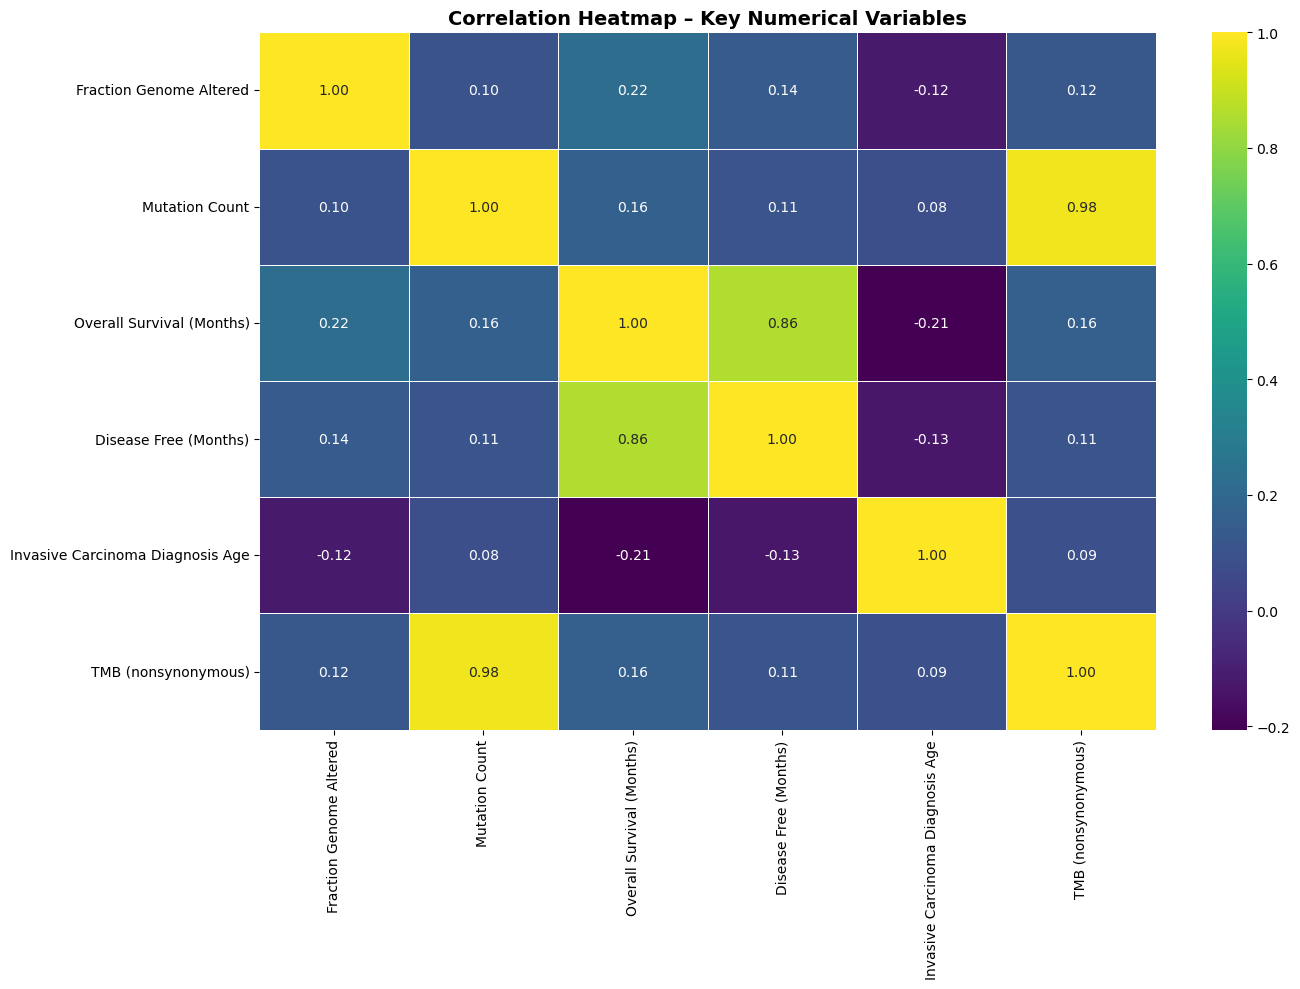

In [45]:
#heat map
plt.figure(figsize=(14, 10))

corr_matrix = dfb[key_num].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='viridis',
    linewidths=0.5
)

plt.title('Correlation Heatmap – Key Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### **Findings**
Most variable don't have good correlation. the main corelating things are Mutation count and TMB and disease free (months) and overall survival (months). This makes sense because TMB is measuring the density of mutations in the dna and Mutations count, counts the toatal mutations. The disease free (months) and overall survival (months) makes sence because it is much more likely that if a patient is disease free for longer they will survive for longer.

## **Visualization**

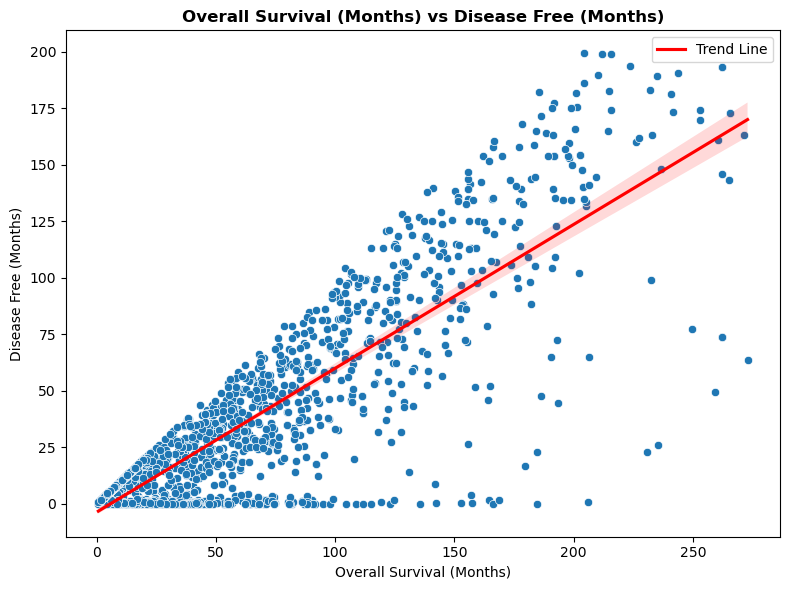

In [48]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Overall Survival (Months)', 
                y='Disease Free (Months)',
                data=dfb)

sns.regplot(x='Overall Survival (Months)', 
                y='Disease Free (Months)',
            data=dfb, scatter=False, color='red', label='Trend Line')

plt.title('Overall Survival (Months) vs Disease Free (Months)', fontweight='bold')
plt.xlabel('Overall Survival (Months)')
plt.ylabel('Disease Free (Months)')

plt.legend()
plt.tight_layout()
plt.show()

This graphs gives more detail on the information that was given from the correlation heat mapp. Although it does show a good positive relationship it also shows some cases where patient did have any disease free months but survived for a long time.

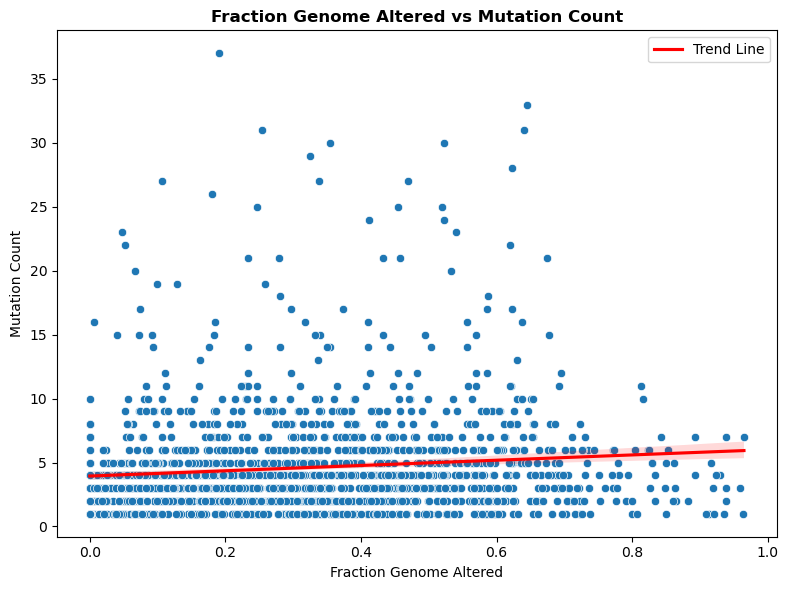

In [30]:
#FGA and Mutations count reg plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Fraction Genome Altered', 
                y='Mutation Count',
                data=dfb)

sns.regplot(x='Fraction Genome Altered', y='Mutation Count',
            data=dfb, scatter=False, color='red', label='Trend Line')

plt.title('Fraction Genome Altered vs Mutation Count', fontweight='bold')
plt.xlabel('Fraction Genome Altered')
plt.ylabel('Mutation Count')

plt.legend()
plt.tight_layout()
plt.show()

### **Findings**


*   There is a slight positive relationship between FGA and Mutation count
*   Most patients are shown to have lower mutations count and FGA but the FGA is more spread out. This indicates that patients are morelikely to have more sever cell damage than number of mutations. 



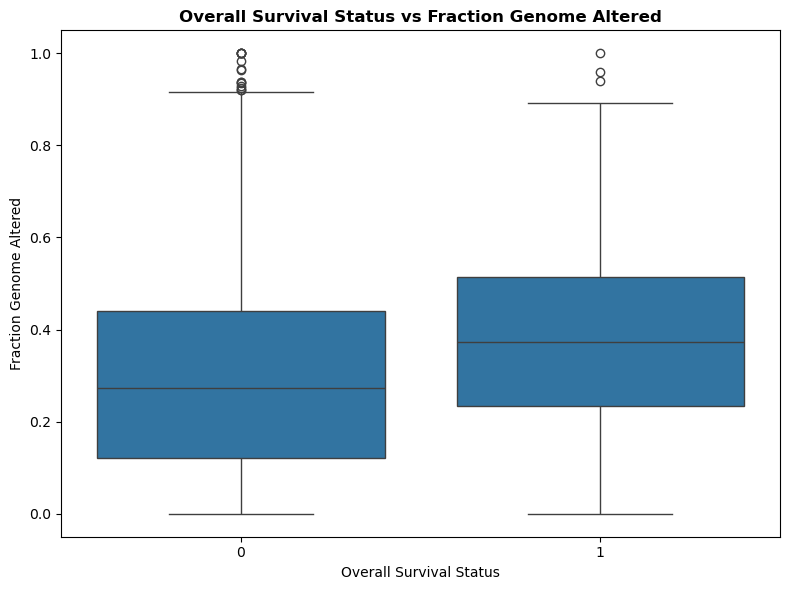

In [32]:
# FGA compared to Overall survival
plt.figure(figsize=(8, 6))
sns.boxplot(x='Overall Survival Status', y='Fraction Genome Altered',
            data=df)
plt.title('Overall Survival Status vs Fraction Genome Altered',
          fontweight='bold')
plt.xlabel('Overall Survival Status')
plt.ylabel('Fraction Genome Altered')

plt.tight_layout()
plt.show()



### **Findings**
In these graph 0 is living and 1 is dead. The box plot does show that patient whom have died have higher mean FGA than those who are living but there is a big spread of data.


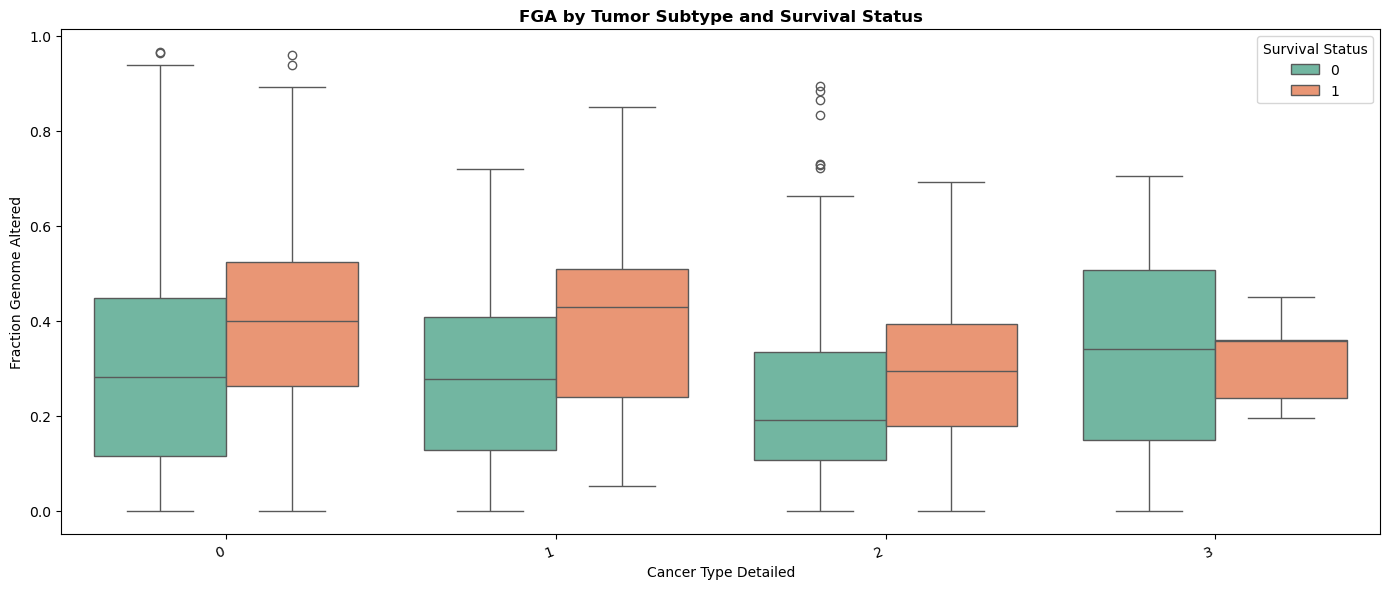

In [51]:
#seeing what subtypes of breast cancer have what overall survival by FGA

top_subtypes = dfb['Cancer Type Detailed'].value_counts().nlargest(4).index
df_sub = dfb[dfb['Cancer Type Detailed'].isin(top_subtypes)]

plt.figure(figsize=(14, 6))
sns.boxplot(x='Cancer Type Detailed', y='Fraction Genome Altered',
            hue='Overall Survival Status', data=df_sub, palette='Set2')
plt.title('FGA by Tumor Subtype and Survival Status', fontweight='bold')
plt.xlabel('Cancer Type Detailed')
plt.ylabel('Fraction Genome Altered')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Survival Status')

plt.tight_layout()
plt.show()

### **Findings**

*******
The graphs show that most Cancer types have a higher FGA for those who died with the excepton of the last one which is breast invasive cancer. This may be primeraly becasue there is a lot less data on that cancer type which makes the spread of data very small. Overall the results are the same as the previous graph.


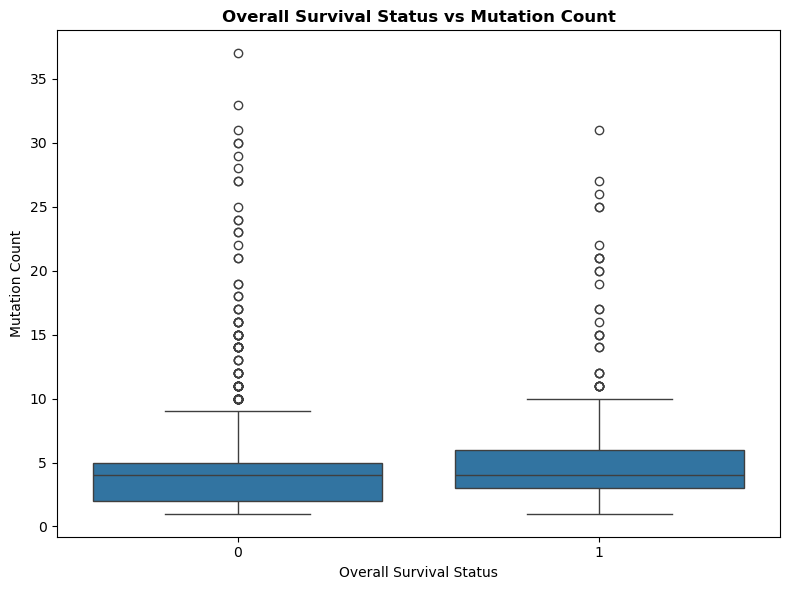

In [35]:
#testing mutations count compared to Overall Survivals

plt.figure(figsize=(8, 6))
sns.boxplot(x='Overall Survival Status', 
            y='Mutation Count',
            data=dfb)
plt.title('Overall Survival Status vs Mutation Count',
           fontweight='bold')
plt.xlabel('Overall Survival Status')
plt.ylabel('Mutation Count')

plt.tight_layout()
plt.show()

### **Findings**

*******
Because the majority of patient have fairly little mutations, which was shown in the distribution from earlier, the means form both box plots are the same and there are many outliers. This shows that there is no relationship between mutation count and overall survival status. 


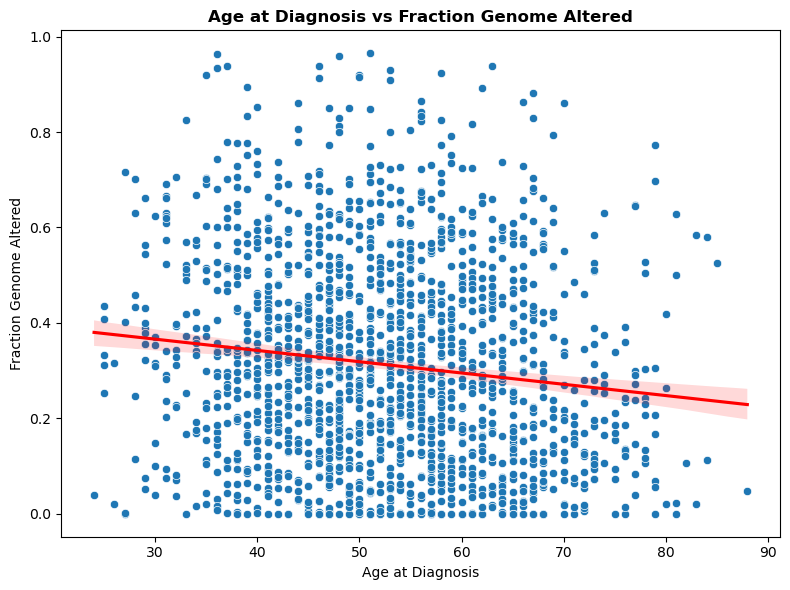

In [37]:
# Seeing the relationship between Age at diagnoses and FGA

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Invasive Carcinoma Diagnosis Age', y='Fraction Genome Altered',
                data=dfb)
sns.regplot(x='Invasive Carcinoma Diagnosis Age', y='Fraction Genome Altered',
            data=dfb, scatter=False, color='red', label='Trend Line')

plt.title('Age at Diagnosis vs Fraction Genome Altered', fontweight='bold')
plt.xlabel('Age at Diagnosis')
plt.ylabel('Fraction Genome Altered')

plt.tight_layout()
plt.show()

### **Findings**
*******
There seems to be a very weak nevative relationship between age at diagnosis and FGA which I didn't expect. Since the data is so spread out I'd say that it is inconclusive.


## **Final Summary of Findings**


Before any analysis a total of 8,195 missing values were identified across the dataset. To preserve data quality, any column with more than 50% of its values missing was dropped. The remaining missing numerical values were filled using the median, which was chosen because it dosen't cause extreem outlier effect. Categorical missing values were filled using the mode, for the same reason. This method does have a bias towards specific most common values seemed like the best way to fill the values. To handle outliers the z-score method was used since it doesn't remove all the outlier or change the scale since those are important for medical data. This reduced the dataset from 1,918 to 1,798 rows.

The exploratory data analysis revealed several important patterns. The distributions of FGA, Mutation Count, and TMB were all found to be right-skewed, meaning the majority of patients had relatively low levels of genomic instability and few mutations which sugest that the tumor is less agressive. Overall Survival and Disease Free months were also right-skewed, reflecting that many patients had shorter survival periods or their cancer came back earlier in their follow up. Age at diagnosis, however, followed a roughly normal bell-shaped distribution centered around the mid-50s, which is consistent with known breast cancer incidence trends.

The first hypothesis proposed that patients with higher FGA would have worse overall survival. The boxplot comparing FGA across survival groups showed that deceased patients had a slightly higher median FGA compared to living patients meaning more deceased patients fell in the higher FGA range. While the two groups overlapped the graph provided partial support for this hypothesis. The extended analysis breaking FGA down by tumor subtype also revealed that the relationship between FGA and survival is mostly consistantly higher for deceased patients. The second hypothesis proposed that patients with higher mutation counts would have worse overall survival. The boxplot of Mutation Count by survival status showed was very inconclusive result since the mean were so close to each other and the data was varied. Hypothesis 1 and 2 sugest that patient survival is determined by a lot more complex factor than just these genomatic variables.The third hypothesis proposed that older patients at diagnosis would have higher FGA compared to younger patients. The scatterplot of age at diagnosis versus FGA showed a very weak and slightly negative relationship. The data was spread widely across all age groups with no clear directional pattern, making the finding inconclusive. This hypothesis was not supported.

This project provides real value to both the medical research community and society more broadly.By showing that genomic features such as FGA are correlated with survival, this analysis provides further support for the expanding evidence base for genomic profiling as a potential means of identifying subgroups of high-risk individuals in clinical oncology.

Each line in the dataset stands for an individual who has experienced the breast cancer. The authors of the current paper would like to emphasize the ethical considerations regarding the use of such data in a study since all the participants agreed to sign the statement of informed consent prior to their inclusion in the sample. This is one of the key prerequisites to be considered in any medical-related investigation. However, the current analysis does require acknowledging its limitations, specifically that it is largely composed of IDC patients only. Also, my choice of values used to replace the missing information did reflect a certain bias towards existing values. One may consider including more types of cancer and using machine learning for predicting a survival or treatment plan for patients based on genomics data.